In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

In [ ]:
df = df[df['Quantity'] > 0]

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,354345
Germany,9042
France,8342
EIRE,7238
Spain,2485
Netherlands,2363
Belgium,2031
Switzerland,1842
Portugal,1462


In [ ]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


In [ ]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


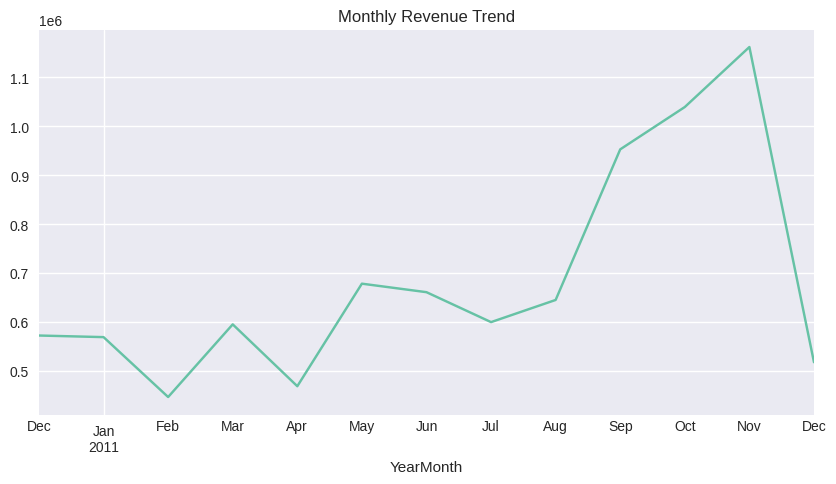

In [ ]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

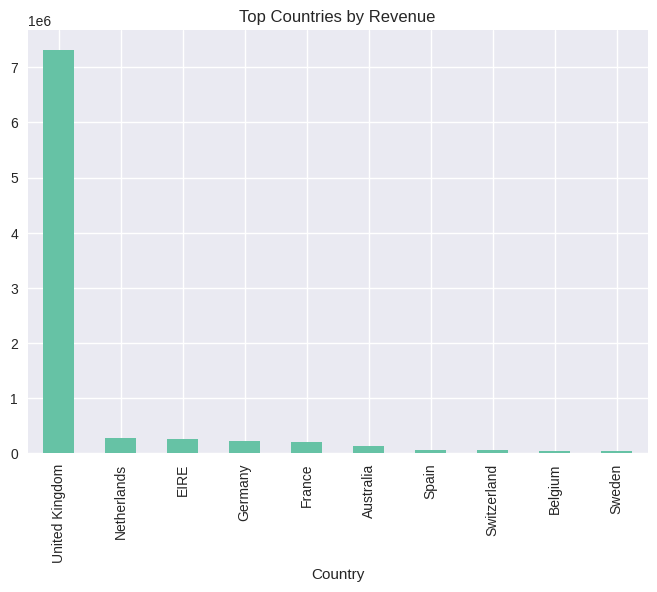

In [ ]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Order Value Distribution')

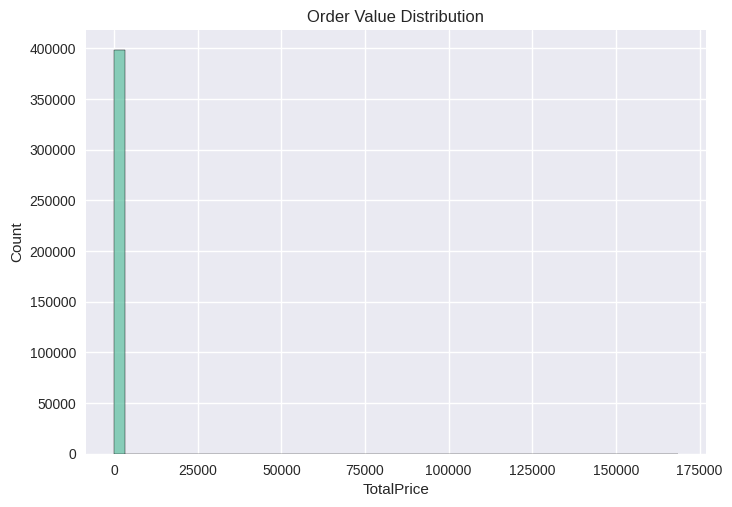

In [ ]:
sns.histplot(df['TotalPrice'], bins=50)
plt.title("Order Value Distribution")

In [ ]:
df['CustomerID'].nunique()

4339

In [ ]:
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum()

customer_revenue.describe()

,TotalPrice
count,4339.000000
mean,2053.793018
std,8988.248381
min,0.000000
25%,307.245000
50%,674.450000
75%,1661.640000
max,280206.020000


In [ ]:
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [ ]:
aov = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()
print(aov)

480.7621873111782


In [ ]:
df.to_csv('Online_Retail_Cleaned.csv', index=False)
print("Cleaned data saved to 'Online_Retail_Cleaned.csv'")

Cleaned data saved to 'Online_Retail_Cleaned.csv'
